<a href="https://colab.research.google.com/github/admmuaka/admmuaka.github.io/blob/main/actuaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [3]:
#path = "/Users/admmuaka/Documents/Master_2/stage2/Actuaria/Actuarial_Task 2 - Claims Data - Template Worksheet (FINAL).xlsx"

path = path = "/content/drive/MyDrive/Actuaria/Actuarial_Task 2 - Claims Data - Template Worksheet (FINAL).xlsx"

xls = pd.ExcelFile(path)
xls.sheet_names





['Claims Data', 'Exploratory Template', 'Pure Premium Work', 'Report']

In [4]:
df = pd.read_excel(xls, sheet_name = "Claims Data")
df['Gross claim amount (HINT: Gross claim amount = Claim incurred + deductible)'] = df['Claim Incurred ($)'] + df['Deductible ($)']
df['Gross inflation adjusted claim (HINT: Gross inflation adjusted claim = gross claim * inflation index)'] = df['Gross claim amount (HINT: Gross claim amount = Claim incurred + deductible)'] * df['Inflation Index']
df['Net inflation adjusted claim  (HINT: Net inflation adjusted claim = Gross inflation adjusted claim - deductible)'] = df['Gross inflation adjusted claim (HINT: Gross inflation adjusted claim = gross claim * inflation index)'] - df['Deductible ($)']
df['Capped net adjusted incurred claim (HINT: Capped net adjusted incurred claim = net inflation adjusted claim capped at policy limit)'] = np.minimum(df['Net inflation adjusted claim  (HINT: Net inflation adjusted claim = Gross inflation adjusted claim - deductible)'],df['Policy Limits ($)'])
df

,Claim ID,Date of Claim,Type of Claim,Claim Incurred ($),Claim Status,Gross claim amount (HINT: Gross claim amount = Claim incurred + deductible),Policy Limits ($),Deductible ($),Cause of Loss,Location,Insured Party,Gross Tonnage,Prior Claims History,Inflation Index,Gross inflation adjusted claim (HINT: Gross inflation adjusted claim = gross claim * inflation index),Net inflation adjusted claim (HINT: Net inflation adjusted claim = Gross inflation adjusted claim - deductible),Capped net adjusted incurred claim (HINT: Capped net adjusted incurred claim = net inflation adjusted claim capped at policy limit),"Attritional claim flag - (set equal to 1 if claim is less than 1m, otherwise 0)",Year
0,CLM-00001,2019-07-18,Collision Liability,737423.28,Closed,749769.20,5000000,12345.92,Human Error,Indian Ocean,Company 9,86815,4,1.147911,8.606681e+05,8.483222e+05,8.483222e+05,1,2019
1,CLM-00002,2020-05-27,Cargo Liability,315189.74,Closed,348906.50,5000000,33716.76,Technical Failure,Atlantic Ocean,Company 4,75801,6,1.103760,3.851092e+05,3.513924e+05,3.513924e+05,1,2020
2,CLM-00003,2018-11-23,Damage to Other Vessels,678364.99,Closed,712761.90,5000000,34396.91,Criminal Activity,Mediterranean Sea,Company 2,45237,3,1.205306,8.590964e+05,8.246995e+05,8.246995e+05,1,2018
3,CLM-00004,2021-01-05,Environmental Pollution,203840.58,Open,215544.46,5000000,11703.88,Natural Disaster,Pacific Ocean,Company 17,91835,7,1.071612,2.309800e+05,2.192761e+05,2.192761e+05,1,2021
4,CLM-00005,2023-06-14,Injury to Third Parties,98692.46,In Litigation,146820.18,1000000,48127.72,Human Error,Indian Ocean,Company 12,6722,8,1.030000,1.512248e+05,1.030971e+05,1.030971e+05,1,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,CLM-00096,2020-02-29,Damage to Other Vessels,573849.48,Closed,606697.06,5000000,32847.58,Criminal Activity,Indian Ocean,Company 7,52109,6,1.103760,6.696482e+05,6.368006e+05,6.368006e+05,1,2020
96,CLM-00097,2019-01-16,Environmental Pollution,572839.45,Closed,605786.90,5000000,32947.45,Natural Disaster,Atlantic Ocean,Company 12,94097,5,1.147911,6.953893e+05,6.624419e+05,6.624419e+05,1,2019
97,CLM-00098,2022-04-14,Cargo Liability,573839.54,Open,601678.92,5000000,27839.38,Technical Failure,Mediterranean Sea,Company 8,57179,3,1.050600,6.321239e+05,6.042845e+05,6.042845e+05,1,2022
98,CLM-00099,2023-08-01,Injury to Third Parties,473839.25,Closed,501321.63,2000000,27482.38,Human Error,Pacific Ocean,Company 19,37152,4,1.030000,5.163613e+05,4.888789e+05,4.888789e+05,1,2023


In [5]:
missing = df.isnull().sum()
missing

,0
Claim ID,0
Date of Claim,0
Type of Claim,0
Claim Incurred ($),0
Claim Status,0
Gross claim amount (HINT: Gross claim amount = Claim incurred + deductible),0
Policy Limits ($),0
Deductible ($),0
Cause of Loss,0
Location,0


In [6]:
# Try to locate key columns

def find_col(keyword):
  for c in df.columns:
    if keyword.lower() in c.lower():
      return c
  return None


incurred_col = find_col("incurred")
incurred_col

year_col = find_col("year")
year_col

status_col = find_col("status")

stats = df[incurred_col].describe()
stats



,Claim Incurred ($)
count,1.000000e+02
mean,5.781023e+05
std,4.889070e+05
min,8.792445e+04
25%,4.489380e+05
50%,5.738395e+05
75%,6.838498e+05
max,5.000000e+06


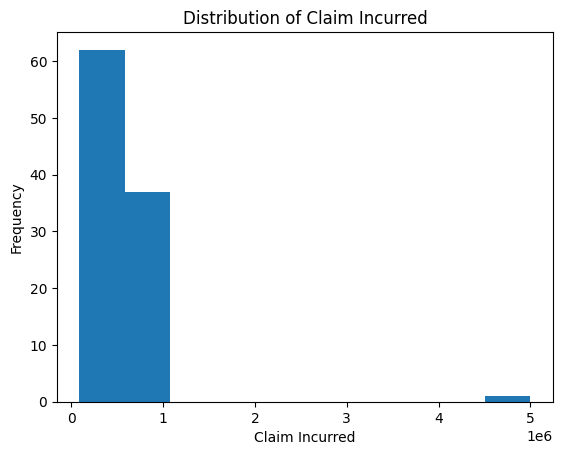

In [7]:
plt.figure()
plt.hist(df[incurred_col].dropna())
plt.title("Distribution of Claim Incurred")
plt.xlabel("Claim Incurred")
plt.ylabel("Frequency")
plt.show()


In [8]:
freq_by_year = df.groupby(year_col).size()
freq_by_year

,0
Year,
2018,10
2019,17
2020,20
2021,20
2022,17
2023,16


In [9]:
freq_by_status = df.groupby(status_col).size()
freq_by_status

,0
Claim Status,
Closed,65
In Litigation,9
Open,26


In [10]:
type_col = find_col("type")
freq_by_type = df.groupby(type_col).size()
dist = (freq_by_type/freq_by_type.sum() * 100).round(2)
dist = dist.sort_values(ascending= False)
dist

,0
Type of Claim,
Environmental Pollution,22.0
Collision Liability,21.0
Damage to Other Vessels,20.0
Cargo Liability,19.0
Injury to Third Parties,18.0


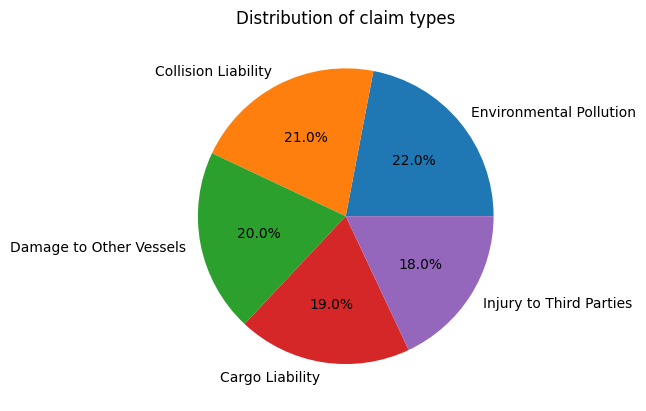

In [11]:
plt.figure()
plt.pie(dist, labels=dist.index, autopct='%1.1f%%')
plt.title("Distribution of claim types")
plt.show()



In [12]:
severy_by_type = df.groupby(type_col)[incurred_col].mean().sort_values(ascending=False).round(0)
severy_by_type

,Claim Incurred ($)
Type of Claim,
Environmental Pollution,790953.0
Damage to Other Vessels,576541.0
Cargo Liability,543965.0
Collision Liability,517299.0
Injury to Third Parties,426658.0


In [13]:
location_col = find_col("location")
severy_by_location = df.groupby(location_col)[incurred_col].agg(['count','mean']).sort_values('mean',ascending=False).round(0)
severy_by_location

,count,mean
Location,,
Atlantic Ocean,23,776742.0
Mediterranean Sea,19,608144.0
Pacific Ocean,20,530582.0
North Sea,20,489394.0
Indian Ocean,18,443941.0


In [14]:
cause_col = find_col("cause")
severy_by_cause = df.groupby(cause_col)[incurred_col].agg(['count','mean']).sort_values('mean',ascending=False).round(0)
severy_by_cause

,count,mean
Cause of Loss,,
Natural Disaster,21,808050.0
Criminal Activity,21,558383.0
Technical Failure,35,527730.0
Human Error,23,462808.0


In [15]:
Exposure = pd.DataFrame({
    'Year' : [2018, 2019, 2020, 2021, 2022, 2023],
    'GrossTonnage' : [45000000,49000000,41750000,41500000,43590000,44750000]
})

Exposure

,Year,GrossTonnage
0,2018,45000000
1,2019,49000000
2,2020,41750000
3,2021,41500000
4,2022,43590000
5,2023,44750000


In [16]:
# Large loss flag by inccured > 1m by assumptions

df['large_loss'] = df[incurred_col] > 1000000

counts = df.loc[~df['large_loss']].groupby(year_col).size().reindex(Exposure['Year'], fill_value=0)
Capped_net_adj = find_col("capped")
sev_sum = df.loc[~df['large_loss']].groupby(year_col)[Capped_net_adj].sum().reindex(Exposure['Year'], fill_value=0)
sev_avg = sev_sum / counts
freq = counts.values/Exposure['GrossTonnage'].values
expected_loss_per_unit =  freq * sev_avg


summary = pd.DataFrame({
    'Year' : Exposure['Year'],
    'GrossTonnage' : Exposure['GrossTonnage'],
    'ClaimExlarge': counts.values,
    'Frequency' : freq,
    'Severety' : sev_avg.values,
    'Expected_loss_per_unit' : expected_loss_per_unit.values



})

summary




,Year,GrossTonnage,ClaimExlarge,Frequency,Severety,Expected_loss_per_unit
0,2018,45000000,10,2.222222e-07,642823.156190,0.142850
1,2019,49000000,17,3.469388e-07,609716.994553,0.211534
2,2020,41750000,20,4.790419e-07,603662.111005,0.289179
3,2021,41500000,20,4.819277e-07,598316.366803,0.288345
4,2022,43590000,16,3.670567e-07,609483.538041,0.223715
5,2023,44750000,16,3.575419e-07,465367.338069,0.166388


In [17]:
avg_freq_simple = summary['Frequency'].mean()
avg_sev_simple = summary['Severety'].mean()
expected_gt_2024 = 40000000
pure_premium_simple = avg_freq_simple * avg_sev_simple * expected_gt_2024

avg_freq_total = counts.sum()/Exposure['GrossTonnage'].sum()
avg_sev_total = sev_sum.sum()/counts.sum()
pure_premium_total = avg_freq_total * avg_sev_total * expected_gt_2024

large_row = df.loc[df['large_loss']].iloc[0]
large_loss_adj = large_row[Capped_net_adj]
large_loss_loading = large_loss_adj/20


for name,val in [('avg_freq_simple',avg_freq_simple),('avg_sev_simple',avg_sev_simple),('pure_premium_simple',pure_premium_simple),('avg_freq_total',avg_freq_total),('avg_sev_total',avg_sev_total),('pure_premium_total',pure_premium_total),('large_loss_adj',large_loss_adj),('large_loss_loading',large_loss_loading)]:
    print(name,val)

avg_freq_simple 3.757881980928946e-07
avg_sev_simple 588228.250776698
pure_premium_simple 8841969.377068426
avg_freq_total 3.727549983056591e-07
avg_sev_total 586167.7176081722
pure_premium_total 8739877.863354653
large_loss_adj 5253947.423774
large_loss_loading 262697.3711887


In [18]:
total_risk_premium = pure_premium_simple + large_loss_loading
final_premium = total_risk_premium * 1.30 *  1.10
total_risk_premium ,final_premium

for name,val in [('total_risk_premium',total_risk_premium),('final_premium',final_premium)]:
    print(name,val)

total_risk_premium 9104666.748257127
final_premium 13019673.450007694


In [19]:
#Scenario: 6% increase in average loss severity
pure_premium_simple_6 = pure_premium_simple * 1.06
large_loss_loading_6 = large_loss_loading * 1.06
total_risk_premium_6 = pure_premium_simple_6 + large_loss_loading_6
final_premium_6 = total_risk_premium_6 * 1.30 *  1.10

for name,val in [('total_risk_premium_6',total_risk_premium_6),('final_premium_6',final_premium_6)]:
    print(name,val)


total_risk_premium_6 9650946.753152555
final_premium_6 13800853.857008155


Ce rapport analyse la tarification de l'assurance reponsabilité maritime à partir des données de sinistres couvrant la période de 2018 à 2023.
L'objectif est d'évaluer les principaux éléments nécessaires à la détermination des primes en s'appuyant sur l'expérience historique des sinistres.

Les principaux axes d'analyse incluent l'évolution de la fréquence des sinistres , la distribution et le niveau de sévérité, l'impact des sinistres majeurs par rapport aux sinistres attritionnels, ainsi que l'ajustement des montants pour tenir compte de l'inflation.
L'effet des franchises et des limites de garantie est également pris en compte dans l'évaluation des coûts finaux.

Les résultats de cette analyse constituent une base essentielle pour l'estimation de la prime pure et pour la mise en place d'une strategie de tarification adaptée

Les variables principales:

1. Type et cause du sinistre
2. Statut du sinistre
3. Les variables financières\
Claim incurred: le coût total estimé du sinitre\
Gross claim amount: montant brut payé\
Montant ajustés à l'inflation: pour comparer correctement dans le temps
4. Caractéristique de la police d'assurance\
Policy limits: montant maximum de remboursé\
Deductibles(franchise): par que l'assuré paie lui-même

5. Variables d'exposition\
Gross tonnage: taille/volume assuré\
Historique des sinistres

Le dataset sépare:\
Attritionals claims(fréquents mais peu couteux) < à 1 million de dollars\
Large losses (rares mais très couteux) environ 5 million de dollars

Donc une distribution des sinistres asymétrique

Les sinistres liés à la pollution environnementale présentent la sévérité moyenne la plus élevée, avec un montant d’environ 791 000 dollars, ce qui en fait le risque le plus coûteux d’un point de vue financier, bien qu’ils ne soient pas les plus fréquents. À l’inverse, les sinistres liés aux dommages corporels à des tiers affichent la sévérité moyenne la plus faible, autour de 427000 dollars.\
Les autres types de sinistres dommages à d’autres navires, responsabilité liée à la cargaison et responsabilité en cas de collision présentent des niveaux de sévérité moyenne relativement proches, compris entre environ 500000 et 580000 dollars.
La localisation la plus coûteuse en moyenne c'est l'Atlantic Ocean.
Le "Technical Failure" est la cause la plus fréquente mais moins coûteuse contrairement à la "Natural Disaster" moins fréquente mais plus sévère

Le calcul repose sur les hypothèses suivantes :
Les sinistres observés entre 2018 et 2023 sont représentatifs du futur
Les périodes de police vont du 1er janvier au 31 décembre
Aucun ajustement de développement des sinistres n’est nécessaire
Les franchises restent inchangées pour la période à venir
Le sinistre majeur est exclu de l’analyse fréquence/sévérité et traité séparément
Le sinistre majeur survient une fois tous les 20 ans
Les chargements sont fixés à :
30 % pour les frais
10 % pour la marge
0 % pour la commission

La prime finale = le prix que l’assureur doit facturer au client = 13 019 673 $
C’est le montant que le client doit payer pour être assuré en 2024.

Supposons que la sévérité de tous les sinistres augmente de 6%, alors la prime finale devient 13800853 $.

Cela représente une augmentation de 781.178 $

**Conclusion**

Ce rapport a permis d’évaluer la tarification d’un portefeuille d’assurance responsabilité maritime à partir de données de sinistres couvrant la période 2018 à 2023. En utilisant une approche de prime pure, l’analyse a combiné la fréquence et la sévérité des sinistres afin d’estimer le coût attendu des pertes et de déterminer une prime appropriée pour 2024.

Les résultats montrent que la fréquence des sinistres est globalement stable dans le temps, tandis que la sévérité est plus volatile et fortement influencée par des événements de grande ampleur. En particulier, les sinistres liés à la pollution environnementale ainsi que les sinistres majeurs constituent les principaux facteurs de risque du portefeuille.

L’intégration d’un chargement pour sinistres majeurs, basé sur une période de retour de 20 ans, permet de prendre en compte ces événements rares mais coûteux dans la tarification. Par ailleurs, l’analyse de sensibilité met en évidence une forte dépendance de la prime à la sévérité des sinistres, soulignant l’importance de bien anticiper les effets de l’inflation et des pertes extrêmes.

Au final, la prime estimée d’environ 13,0 millions de dollars apparaît cohérente au regard de l’expérience historique et du profil de risque du portefeuille. Néanmoins, un suivi régulier de l’évolution des sinistres, en particulier des sinistres majeurs, reste essentiel pour garantir la pertinence de la tarification.


